For making the final presentation plots that don't really fit anywhere else.

#1. Radar plots of our interests

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<Axes: title={'center': 'Where we started'}>

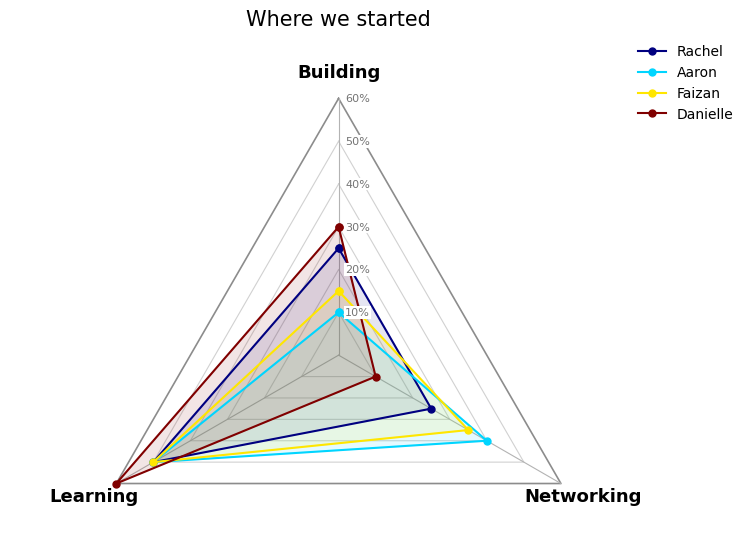

In [2]:
def triangular_radar(data, categories=("Learning", "Networking", "Building"),
                     angles=(210, 330, 90), rmax=None, step=10, cmap="jet",
                     title=None, ax=None):
    """Triangular radar plot. `data` maps each name to 3 values.
    `angles` gives the vertex position in degrees for each category, in the
    same order as `categories` and the data values."""
    ang = np.deg2rad(angles)
    xy = lambda v: (np.asarray(v, float) * np.cos(ang), np.asarray(v, float) * np.sin(ang))
    close = lambda x, y: (np.append(x, x[0]), np.append(y, y[0]))
 
    if rmax is None:
        rmax = step * int(np.ceil(max(max(v) for v in data.values()) / step))
    if ax is None:
        ax = plt.subplots(figsize=(7.5, 6))[1]
    ax.set_aspect("equal"); ax.axis("off")
 
    order = np.argsort(ang % (2 * np.pi))                              # keep rings convex
    for r in np.arange(step, rmax + step, step):
        outer = np.isclose(r, rmax)
        rx, ry = xy([r] * 3)
        ax.plot(*close(rx[order], ry[order]), color="0.55" if outer else "0.82",
                lw=1.2 if outer else 0.8, zorder=1)
        ax.text(rmax * 0.025, r, f"{r:g}%", ha="left", va="center", fontsize=8,
                color="0.45", zorder=6,
                bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
 
    for a, lab in zip(ang, categories):                                # spokes + labels
        ax.plot([0, rmax * np.cos(a)], [0, rmax * np.sin(a)], color="0.7", lw=0.8, zorder=1)
        ax.text(1.1 * rmax * np.cos(a), 1.1 * rmax * np.sin(a), lab,
                ha="center", va="center", fontsize=13, fontweight="bold")
 
    for (name, vals), c in zip(data.items(), plt.get_cmap(cmap)(np.linspace(0, 1, len(data)))):
        vx, vy = xy(vals)
        px, py = close(vx[order], vy[order])
        ax.plot(px, py, color=c, lw=1.5, marker="o", ms=5, label=name, zorder=4)
        ax.fill(px, py, color=c, alpha=0.10, zorder=2)
 
    ax.set_xlim(-rmax * 1.28, rmax * 1.28); ax.set_ylim(-rmax * 0.72, rmax * 1.22)
    ax.legend(loc="upper right", bbox_to_anchor=(1.12, 1.02), frameon=False)
    if title:
        ax.set_title(title, fontsize=15, pad=12)
    plt.tight_layout()
    return ax

data = {
    "Rachel":   [50, 25, 25],
    "Aaron":    [50, 40, 10],
    "Faizan":   [50, 35, 15],
    "Danielle": [60, 10, 30],
}
 
triangular_radar(data, title="Where we started")

(<Figure size 1000x920 with 4 Axes>,
 array([<Axes: title={'center': 'Rachel'}>,
        <Axes: title={'center': 'Aaron'}>,
        <Axes: title={'center': 'Faizan'}>,
        <Axes: title={'center': 'Danielle'}>], dtype=object))

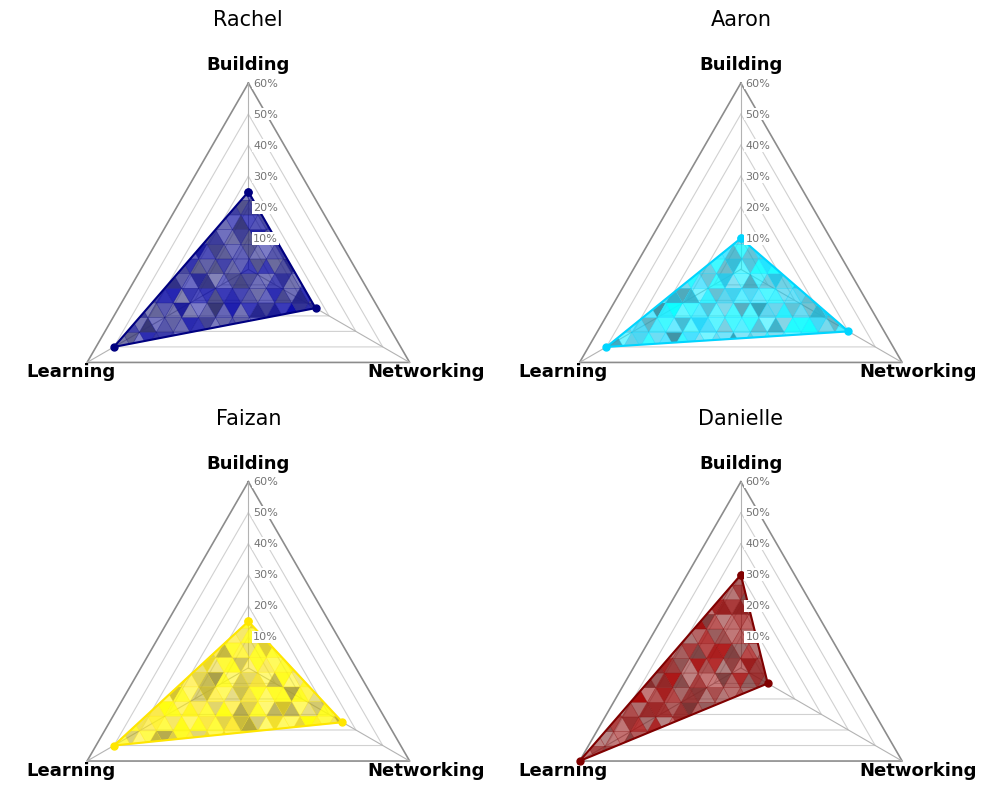

In [3]:
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection
from matplotlib.patches import Polygon
 
 
def _scale_fill(ax, verts, color, size, seed=0, alpha=(0.25, 0.95), zorder=3):
    """Tile the polygon `verts` with jittered triangles in shades of `color`."""
    rng = np.random.default_rng(seed)
    (xmin, ymin), (xmax, ymax) = verts.min(0), verts.max(0)
    s = size
    h = s * np.sqrt(3) / 2
 
    tris = []
    for j in range(int((ymax - ymin) / h) + 2):
        y0, off = ymin + j * h, (j % 2) * s / 2
        for i in range(-1, int((xmax - xmin) / s) + 2):
            x0 = xmin + i * s + off
            tris.append([(x0, y0), (x0 + s, y0), (x0 + s / 2, y0 + h)])
            tris.append([(x0 + s / 2, y0 + h), (x0 + 3 * s / 2, y0 + h), (x0 + s, y0)])
    tris = np.array(tris)
 
    base = np.array(mcolors.to_rgb(color))
    t = rng.random((len(tris), 1))
    face = np.clip(base * (0.60 + 0.75 * t) + 0.22 * (1 - t) * (1 - base), 0, 1)
    a = alpha[0] + (alpha[1] - alpha[0]) * rng.random((len(tris), 1))
 
    clip = Polygon(verts, transform=ax.transData, fc="none", ec="none")
    ax.add_patch(clip)
    under = Polygon(verts, fc=color, alpha=0.35, ec="none", zorder=zorder - 0.5)
    ax.add_patch(under)                                # hides grid under the scales
    pc = PolyCollection(tris, facecolors=np.hstack([face, a]),
                        edgecolors=mcolors.to_rgba(color, 0.30), lw=0.4, zorder=zorder)
    pc.set_clip_path(clip)
    ax.add_collection(pc)
    return pc
 
 
def triangular_radar_panels(data, categories=("Learning", "Networking", "Building"),
                            angles=(210, 330, 90), rmax=None, step=10, cmap="jet",
                            ncols=2, scale_n=11, suptitle=None, panel_size=(5.0, 4.6)):
    """One panel per participant, colours matched to triangular_radar's jet order."""
    names = list(data)
    if rmax is None:                                   # shared scale across panels
        rmax = step * int(np.ceil(max(max(v) for v in data.values()) / step))
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(names)))
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel_size[0] * ncols, panel_size[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
 
    for k, (name, c) in enumerate(zip(names, colors)):
        ax = axes[k]
        triangular_radar({name: data[name]}, categories=categories, angles=angles,
                         rmax=rmax, step=step, ax=ax, title=name)
        if ax.get_legend():
            ax.get_legend().remove()
        ax.lines[-1].set_color(c)                      # outline + markers
        fill = ax.patches[-1]
        verts = fill.get_xy()[:-1]
        fill.set_facecolor("none")                     # replace flat fill with scales
        _scale_fill(ax, verts, c, size=rmax / scale_n, seed=k)
 
    for ax in axes[len(names):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, y=1.0)
    fig.tight_layout()
    return fig, axes
 
 
data = {
    "Rachel":   [50, 25, 25],
    "Aaron":    [50, 40, 10],
    "Faizan":   [50, 35, 15],
    "Danielle": [60, 10, 30],
}
triangular_radar_panels(data, suptitle=None)


In [ ]:
data_final = {
    "Rachel":   [60, 20, 20],
    "Aaron":    [33, 33, 34],
    "Faizan":   [45, 50, 5],
    "Danielle": [50, 25, 25],
}
triangular_radar_panels(data_final, suptitle=None)

Want to make a triangle mesh of Canada - the ones online are all copyright

1429 vertices, 1942 triangles


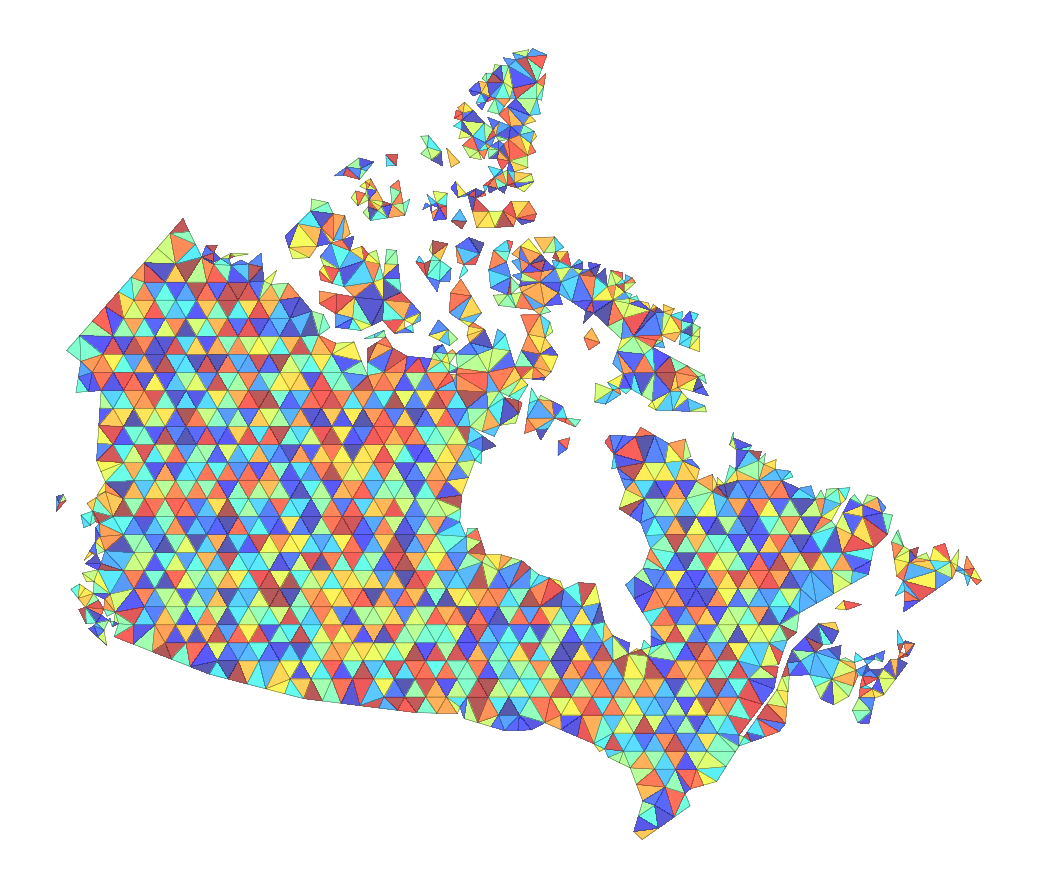

In [5]:
import json
import urllib.request
 
import numpy as np
import matplotlib.pyplot as plt
import shapely
from pyproj import Transformer
from scipy.spatial import Delaunay
from shapely.geometry import shape, MultiPolygon
from shapely.ops import transform as shp_transform
 
NE_URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
          "master/geojson/ne_50m_admin_0_countries.geojson")
 
 
def load_country(name="Canada", url=NE_URL, crs="EPSG:3978"):
    """Fetch a country outline and project it to a planar CRS (metres)."""
    feats = json.load(urllib.request.urlopen(url))["features"]
    geom = shape(next(f["geometry"] for f in feats
                      if f["properties"]["ADMIN"] == name))
    tf = Transformer.from_crs("EPSG:4326", crs, always_xy=True).transform
    return shp_transform(tf, geom)
 
 
def prep(geom, min_area_km2=5_000, simplify_km=25):
    """Drop small islands and simplify. Units are projected metres."""
    parts = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
    parts = [p for p in parts if p.area >= min_area_km2 * 1e6]
    parts = [p.simplify(simplify_km * 1e3, preserve_topology=True) for p in parts]
    parts = [p for p in parts if p.is_valid and not p.is_empty]
    return MultiPolygon(parts) if len(parts) > 1 else parts[0]
 
 
def _ring_points(geom):
    """Every vertex of every ring, exterior and interior."""
    out = []
    for poly in (geom.geoms if isinstance(geom, MultiPolygon) else [geom]):
        out.append(np.asarray(poly.exterior.coords)[:-1])
        out.extend(np.asarray(r.coords)[:-1] for r in poly.interiors)
    return np.vstack(out)
 
 
def _hex_lattice(geom, d, jitter=0.0, seed=0):
    """Interior points on a staggered lattice, inset from the boundary."""
    inner = geom.buffer(-0.5 * d)
    if inner.is_empty:
        return np.empty((0, 2))
    minx, miny, maxx, maxy = inner.bounds
    dy = d * np.sqrt(3) / 2
    rows = []
    for j, y in enumerate(np.arange(miny, maxy + dy, dy)):
        x = np.arange(minx + (j % 2) * d / 2, maxx + d, d)
        rows.append(np.column_stack([x, np.full_like(x, y)]))
    pts = np.vstack(rows)
    if jitter:
        pts += np.random.default_rng(seed).uniform(-jitter * d, jitter * d, pts.shape)
    return pts[shapely.contains_xy(inner, pts[:, 0], pts[:, 1])]
 
 
def mesh(geom, cell_km=120, jitter=0.0, seed=0):
    """Return (vertices, triangles). `cell_km` sets the target edge length."""
    d = cell_km * 1e3
    dense = shapely.segmentize(geom, d)          # boundary edges ~ interior spacing
    pts = np.vstack([_ring_points(dense), _hex_lattice(geom, d, jitter, seed)])
    pts = np.unique(pts, axis=0)
 
    tris = Delaunay(pts).simplices
    cent = pts[tris].mean(axis=1)                # keep only what's inside
    keep = shapely.contains_xy(geom, cent[:, 0], cent[:, 1])
    return pts, tris[keep]
 
geom = prep(load_country("Canada"))
v, t = mesh(geom, cell_km=120)
print(f"{len(v)} vertices, {len(t)} triangles")

fig, ax = plt.subplots(figsize=(11, 9))
ax.tripcolor(v[:, 0], v[:, 1], t,
                facecolors=np.random.default_rng(0).random(len(t)),
                cmap="jet", alpha=0.65, edgecolors="none")
ax.triplot(v[:, 0], v[:, 1], t, color="0.35", lw=0.35)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()
fig.savefig("/tmp/canada_mesh2.png", dpi=130, bbox_inches="tight",
            facecolor="white")
